In [ ]:
!pip install pyDOE3 pandas numpy matplotlib seaborn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd

In [ ]:
from pyDOE3 import bbdesign

-1 low 0 centre +1 high.centre values are at last

In [ ]:
design = bbdesign(3)
df=pd.DataFrame(design,columns=["temperature","ph","substrate"])
print(df)


    temperature   ph  substrate
0          -1.0 -1.0        0.0
1          -1.0  1.0        0.0
2           1.0 -1.0        0.0
3           1.0  1.0        0.0
4          -1.0  0.0       -1.0
5          -1.0  0.0        1.0
6           1.0  0.0       -1.0
7           1.0  0.0        1.0
8           0.0 -1.0       -1.0
9           0.0 -1.0        1.0
10          0.0  1.0       -1.0
11          0.0  1.0        1.0
12          0.0  0.0        0.0
13          0.0  0.0        0.0
14          0.0  0.0        0.0


In [ ]:
temp_map={-1:30,0:30,1:35}
ph_map={-1:5,0:6,1:7}
temp_map={-1:1,0:2,1:3}
df['temperature']=df['temperature'].map(temp_map)
df['ph']=df['ph'].map(ph_map)
df['substrate']=df['substrate'].map(temp_map)
print(df)


    temperature  ph  substrate
0             1   5          2
1             1   7          2
2             3   5          2
3             3   7          2
4             1   6          1
5             1   6          3
6             3   6          1
7             3   6          3
8             2   5          1
9             2   5          3
10            2   7          1
11            2   7          3
12            2   6          2
13            2   6          2
14            2   6          2


we need actual experimetalconditions hence convert coded values into actual data

here activity is the response ,the objective is to determine which comb of factors produce max activity

In [ ]:
df["activity"]=[65,80,85,95,70,88,90,100,72,86,92,100,89,90,91]
print(df)

    temperature  ph  substrate  activity
0             1   5          2        65
1             1   7          2        80
2             3   5          2        85
3             3   7          2        95
4             1   6          1        70
5             1   6          3        88
6             3   6          1        90
7             3   6          3       100
8             2   5          1        72
9             2   5          3        86
10            2   7          1        92
11            2   7          3       100
12            2   6          2        89
13            2   6          2        90
14            2   6          2        91


In [ ]:
import statsmodels.formula.api as smf

building an rsm model creating a mathematical relationship between inputs temperature,ph,substrate and output as enzyme activity.allows prediction of enzyme activity with the conditions that are not yet tested.

In [ ]:
model =smf.ols(formula="activity~temperature+ph+substrate",data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               activity   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     24.04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           3.93e-05
Time:                        11:07:46   Log-Likelihood:                -40.698
No. Observations:                  15   AIC:                             89.40
Df Residuals:                      11   BIC:                             92.23
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      12.7000     10.052      1.263      

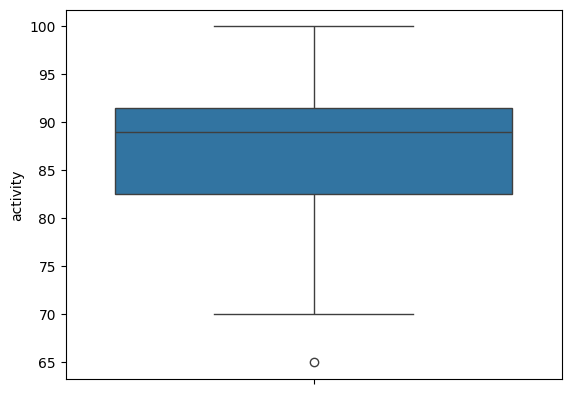

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(y=df["activity"])
plt.show()

biological systems arent linear,response increases reaches max and decreases,a linaer relationship cant depict this behaviourhence we use squared terms

In [ ]:
df["temp2"]=df["temperature"]**2
df["ph2"]=df["ph"]**2
df["sub2"]=df["substrate"]**2

factors often influence each other
eg temperature alone may not increase activity,temperature along with specific ph may increase response dramatically.

In [ ]:
df["temp_ph"]=df["temperature"]*df["ph"]
df["temp_sub"]=df["temperature"]*df["substrate"]
df["ph_sub"]=df["ph"]*df["substrate"]
print(df)

    temperature  ph  substrate  activity  temp2  ph2  sub2  temp_ph  temp_sub  \
0             1   5          2        65      1   25     4        5         2   
1             1   7          2        80      1   49     4        7         2   
2             3   5          2        85      9   25     4       15         6   
3             3   7          2        95      9   49     4       21         6   
4             1   6          1        70      1   36     1        6         1   
5             1   6          3        88      1   36     9        6         3   
6             3   6          1        90      9   36     1       18         3   
7             3   6          3       100      9   36     9       18         9   
8             2   5          1        72      4   25     1       10         2   
9             2   5          3        86      4   25     9       10         6   
10            2   7          1        92      4   49     1       14         2   
11            2   7         

givesus statsistical significance R^2 value,indicating how well the model explains variation in enzyme activity

In [ ]:
model2=smf.ols(formula="activity~temperature+ph+substrate+temp2+ph2+sub2+temp_ph+temp_sub+ph_sub",data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               activity   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     46.66
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           0.000272
Time:                        11:15:54   Log-Likelihood:                -22.547
No. Observations:                  15   AIC:                             65.09
Df Residuals:                       5   BIC:                             72.17
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -185.0000     39.500     -4.684      

ANOVA helps determine whether each factor significantly affects enzyme activity.

In [ ]:
from statsmodels.stats.anova import anova_lm
anovares=anova_lm(model2)
print(anovares)


In [ ]:
df["pred_act"]=model2.predict(df)
print(df[["activity","pred_act"]])

    activity  pred_act
0         65    64.250
1         80    81.500
2         85    83.500
3         95    95.750
4         70    70.375
5         88    86.875
6         90    91.125
7        100    99.625
8         72    72.375
9         86    87.875
10        92    90.125
11       100    99.625
12        89    90.000
13        90    90.000
14        91    90.000


evaluates the model performance if poinys lie close to diagnol line the model predicts accurately.

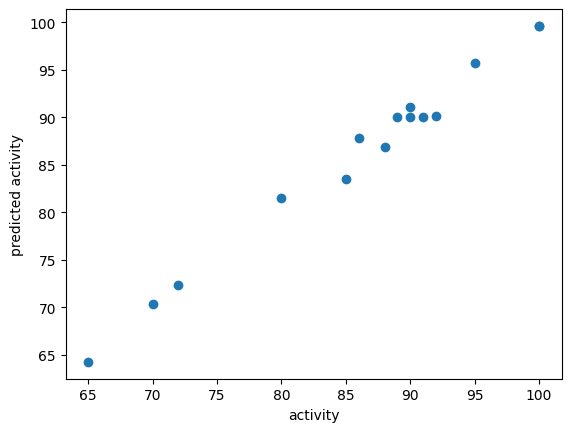

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df["activity"],df["pred_act"])
plt.xlabel("activity")
plt.ylabel("predicted activity")
plt.show()

In [ ]:
df.to_csv("bdbrsm",index=False)
print("done")

done


now predicting response at new conditions w/o doing actual experiment

In [ ]:
new=pd.DataFrame({"temperature":[32],"ph":[6.5],"substrate":[2.5],"temp2":[32**2],"ph2":[6.5**2],"sub2":[2.5**2],"temp_ph":[32*6.5],"temp_sub":[32*2.5],"ph_sub":[6.5*2.5]})
prediction=model2.predict(new)
print("predicted activity:")
print(prediction)

predicted activity:
0   -3864.1875
dtype: float64


In [ ]:
plt.savefig("pred_vs_actual.png")

<Figure size 640x480 with 0 Axes>